## Read Dataset

In [29]:
import pandas as pd

df = pd.read_csv("netflix_titles_nov_2019.csv")
df.head()


,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [30]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5837 non-null   int64 
 1   title         5837 non-null   object
 2   director      3936 non-null   object
 3   cast          5281 non-null   object
 4   country       5410 non-null   object
 5   date_added    5195 non-null   object
 6   release_year  5837 non-null   int64 
 7   rating        5827 non-null   object
 8   duration      5837 non-null   object
 9   listed_in     5837 non-null   object
 10  description   5837 non-null   object
 11  type          5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


,0
show_id,0
title,0
director,1901
cast,556
country,427
date_added,642
release_year,0
rating,10
duration,0
listed_in,0


## Handling Missing Values

- Filled categorical columns with 'Unknown'
- Used mode for rating
- Converted date_added to datetime and handled missing values

In [31]:
# Fill Categorical Columns

df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna('unknown')

In [32]:
# Fix rating

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [33]:
# Fix date_added

df['date_added'] = pd.to_datetime(df['date_added'])
df['date_added'] = df['date_added'].fillna(method='ffill')

/tmp/ipykernel_24050/2851226043.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date_added'] = df['date_added'].fillna(method='ffill')


In [34]:
df.isnull().sum()

,0
show_id,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [35]:
# Extract year from date_added

df['year_added'] = df['date_added'].dt.year

## EDA

### Movies vs TV Shows
- Netflix has a higher number of Movies compared to TV Shows
- Movies dominate the platform’s content library

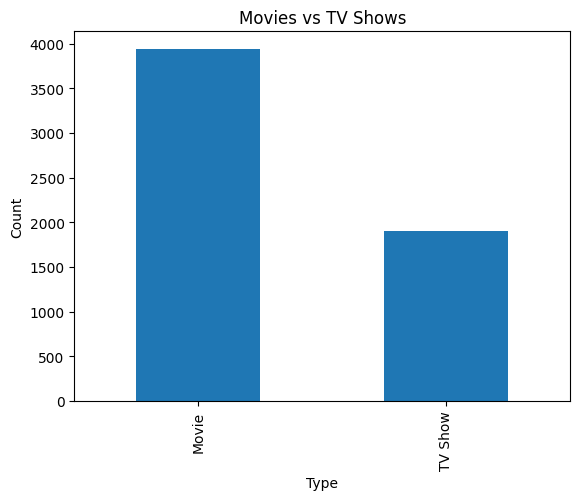

In [36]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel('Count')
plt.show()

### Top 10 Countries
- United States produces the highest amount of content
- India is the second-largest contributor
- A significant portion of data has 'Unknown' country, indicating missing or unclear data

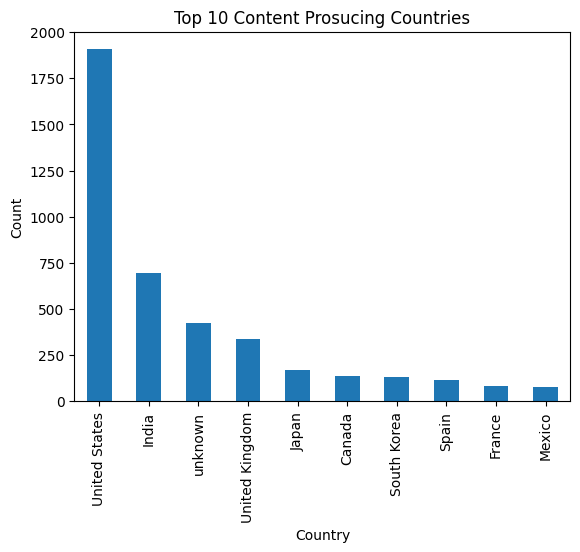

In [37]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Content Prosucing Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

### Content Added Over Years
- Netflix content increased rapidly after 2015
- Peak growth observed between 2016–2019
- This reflects Netflix’s global expansion strategy

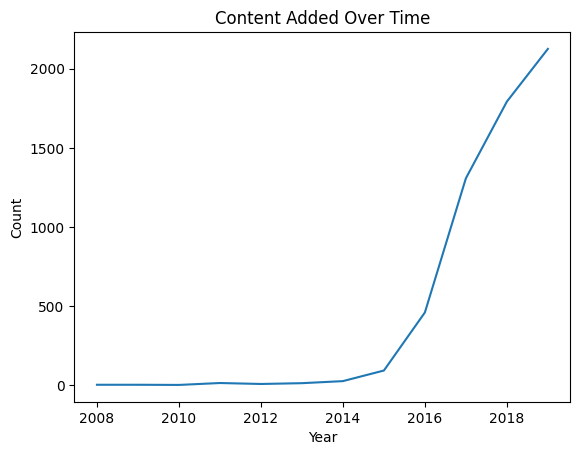

In [38]:
df['year_added'].value_counts().sort_index().plot()
plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

### Most Common Ratings
- Most content is targeted towards mature audiences (TV-MA, TV-14)
- Limited content for children compared to adult categories

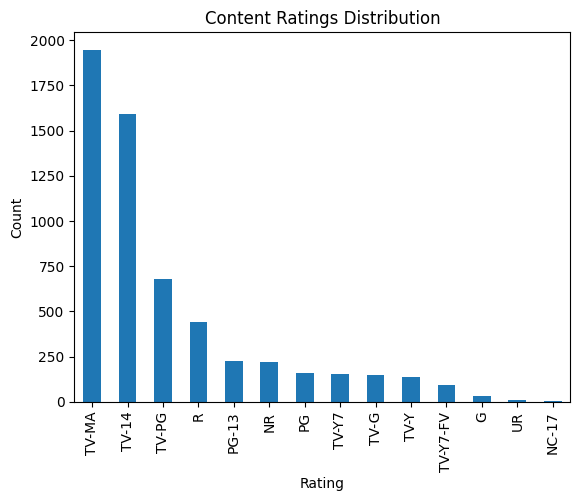

In [39]:
df['rating'].value_counts().plot(kind='bar')
plt.title('Content Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Top Genres
- Documentaries and Stand-Up Comedy are among the most popular genres
- International content plays a significant role on Netflix

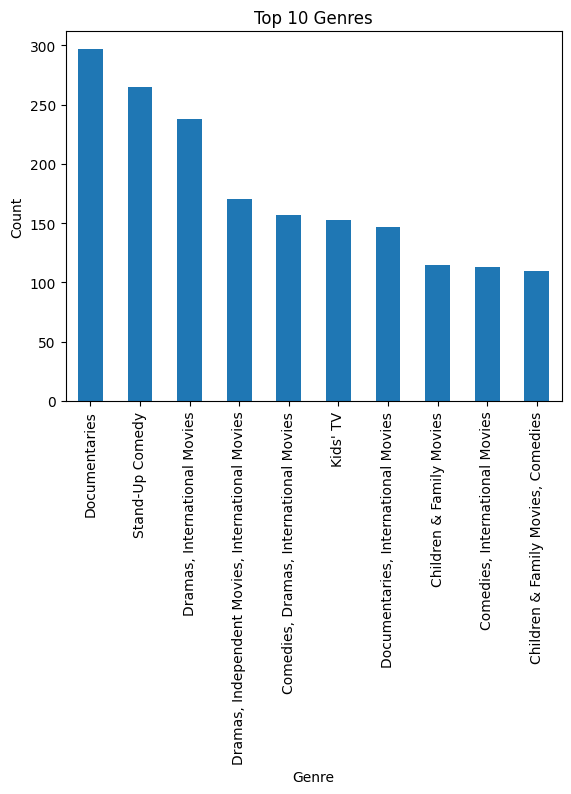

In [40]:
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

## Machine Learning Model



## 1. Logistic Regression Model 🤖

A Logistic Regression model was implemented as a baseline classification model to predict whether a Netflix title is a Movie or a TV Show.

### Why Logistic Regression?

* Simple and easy to implement
* Works well for binary classification problems
* Provides a good baseline for comparison

### Features Used

* `release_year`
* `rating`
* `year_added`

### Model Training

The dataset was split into training and testing sets using an 80-20 split. The Logistic Regression model was trained on the training data and evaluated on the test data.

### Results

* Accuracy: **67.4%**

### Conclusion

The Logistic Regression model achieved moderate accuracy. However, its performance is lower compared to the Decision Tree model, suggesting that the dataset may contain non-linear patterns.

### Limitations

* Assumes a linear relationship between features and target
* Limited ability to capture complex patterns

### Future Improvements

* Feature engineering to include more relevant variables
* Trying non-linear models for better performance


In [41]:
# Import Libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Encode Categorical Data

le = LabelEncoder()

df['rating'] = le.fit_transform(df['rating'])
df['type'] = le.fit_transform(df['type'])



In [42]:
# Define features and target

X = df[['release_year', 'rating', 'year_added']]
y = df['type']

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [43]:
# Train model

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Check Accuracy

accuracy = model.score(X_test, y_test)
print('Accuracy: ', accuracy)

Accuracy:  0.708904109589041


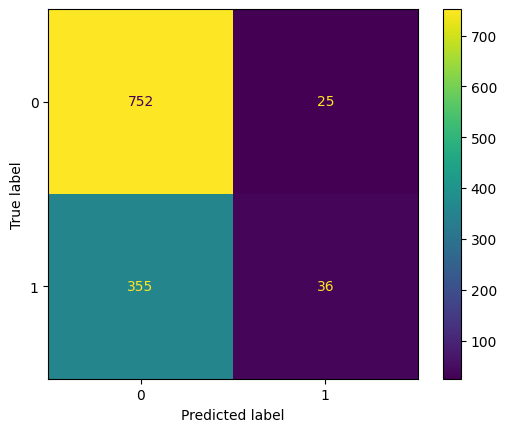

In [44]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = log_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.97      0.80       777
           1       0.59      0.09      0.16       391

    accuracy                           0.67      1168
   macro avg       0.63      0.53      0.48      1168
weighted avg       0.65      0.67      0.58      1168



### Result
The model achieved an accuracy of 67.46%, indicating reasonable performance for a basic classification task.

## 2. Decision Tree Model 🌳

A Decision Tree Classifier was implemented to improve classification performance compared to Logistic Regression.

### Why Decision Tree?

* Handles non-linear relationships effectively
* Easy to interpret and visualize
* Does not require feature scaling

### Features Used

* `release_year`
* `rating`
* `year_added`

### Model Training

The dataset was split into training and testing sets using an 80-20 split. The Decision Tree model was trained on the training data and evaluated on the test data.

### Results

* Accuracy: **70.8%**

### Conclusion

The Decision Tree model performed better than Logistic Regression, indicating that the dataset contains non-linear patterns that are better captured by tree-based models.

### Limitations

* The model may overfit if not properly tuned
* Limited features were used, which may affect performance

### Future Improvements

* Hyperparameter tuning (max_depth, min_samples_split)
* Adding more features (e.g., genre, country)
* Trying ensemble models like Random Forest


In [46]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)

In [47]:
# Compare models

print("Logistic Regression:", log_model.score(X_test, y_test))
print("Decision Tree:", dt_model.score(X_test,y_test))

Logistic Regression: 0.6746575342465754
Decision Tree: 0.7097602739726028


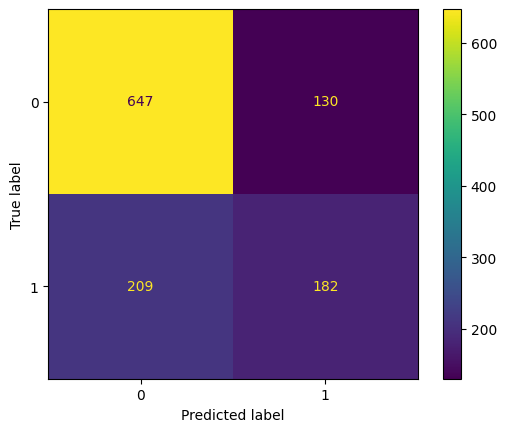

In [48]:
# Confusion Matrix

y_pred = dt_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       777
           1       0.58      0.47      0.52       391

    accuracy                           0.71      1168
   macro avg       0.67      0.65      0.66      1168
weighted avg       0.70      0.71      0.70      1168



## Model Comparison 📊

Two machine learning models were implemented and compared to evaluate their performance in classifying Netflix content as Movies or TV Shows.

### Models Used

* Logistic Regression
* Decision Tree Classifier

### Performance Comparison

| Model               | Accuracy |
| ------------------- | -------- |
| Logistic Regression | 67.4%    |
| Decision Tree       | 70.8%    |

### Analysis

* The Decision Tree model outperformed Logistic Regression by achieving higher accuracy.
* Logistic Regression assumes a linear relationship between features and the target, which may not fully capture the complexity of the dataset.
* Decision Trees can model non-linear patterns, making them more suitable for this dataset.

### Conclusion

The Decision Tree model is more effective for this classification task. However, both models show moderate performance, indicating that further improvements can be made.

### Future Improvements

* Feature engineering (e.g., splitting genres, countries)
* Hyperparameter tuning for Decision Tree
* Trying advanced models like Random Forest


## Classification Report

To evaluate model performance beyond accuracy, a classification report was generated including precision, recall, and F1-score.

### Logistic Regression

* Accuracy: **67%**
* Strong performance for Movies (high recall: 0.97)
* Poor performance for TV Shows (low recall: 0.09)

**Insight:**
The model is biased towards predicting Movies and fails to correctly identify many TV Shows.

---

### Decision Tree

* Accuracy: **71%**
* More balanced performance across both classes
* Improved recall for TV Shows (0.47)

**Insight:**
The Decision Tree model performs better overall and handles class imbalance more effectively.

---

### Conclusion

While Logistic Regression provides a simple baseline, it struggles with class imbalance.
The Decision Tree model demonstrates better generalization and is more suitable for this classification task.

---

### Key Metrics Explained

* **Precision:** How many predicted values are correct
* **Recall:** How many actual values are correctly identified
* **F1-score:** Balance between precision and recall
